In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# Load dataset
df = pd.read_csv("size_trials4.csv", header=None)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(X_scaled.shape)

# Apply PCA over all components to find contribution
pca = PCA(n_components=56)
pca.fit(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Print contribution of each principal component
for i, ratio in enumerate(explained_variance_ratio):
   print(f"Principal Component {i+1}: {ratio:.4f} ({ratio*100:.2f}% of total variance)")

(56, 892)
Principal Component 1: 0.2117 (21.17% of total variance)
Principal Component 2: 0.0467 (4.67% of total variance)
Principal Component 3: 0.0422 (4.22% of total variance)
Principal Component 4: 0.0353 (3.53% of total variance)
Principal Component 5: 0.0327 (3.27% of total variance)
Principal Component 6: 0.0268 (2.68% of total variance)
Principal Component 7: 0.0261 (2.61% of total variance)
Principal Component 8: 0.0235 (2.35% of total variance)
Principal Component 9: 0.0226 (2.26% of total variance)
Principal Component 10: 0.0210 (2.10% of total variance)
Principal Component 11: 0.0204 (2.04% of total variance)
Principal Component 12: 0.0198 (1.98% of total variance)
Principal Component 13: 0.0186 (1.86% of total variance)
Principal Component 14: 0.0179 (1.79% of total variance)
Principal Component 15: 0.0174 (1.74% of total variance)
Principal Component 16: 0.0172 (1.72% of total variance)
Principal Component 17: 0.0163 (1.63% of total variance)
Principal Component 18: 0.015

In [5]:
# Reduce dimensions to 3D using PCA - accounts for > 60% of variance
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

### K means after PCA in 3D

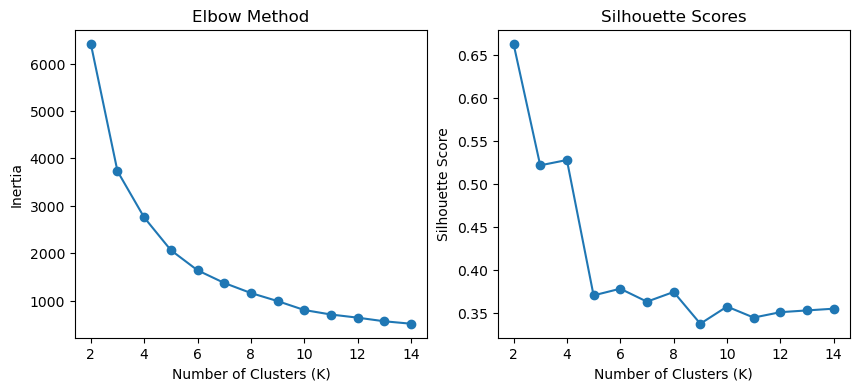

In [5]:
# Find optimal K using the Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 15)  # Test clusters from 2 to 14

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

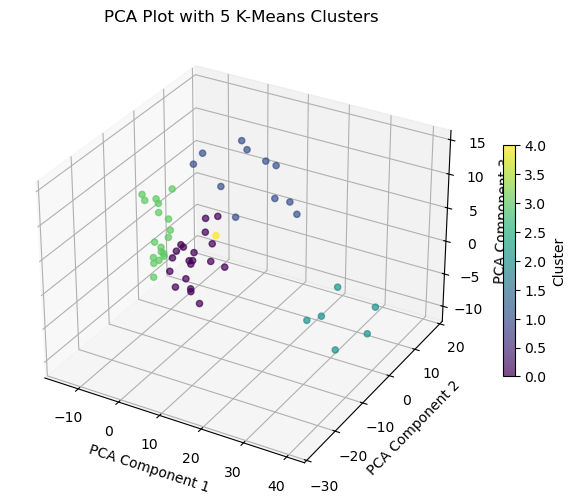

In [6]:
# Apply K-Means clustering on the PCA results
optimal_k = 5  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Plot PCA results with clusters in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Cluster'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title(f"PCA Plot with {optimal_k} K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()


### PCA Component Reduction Labeled by Size in 3D

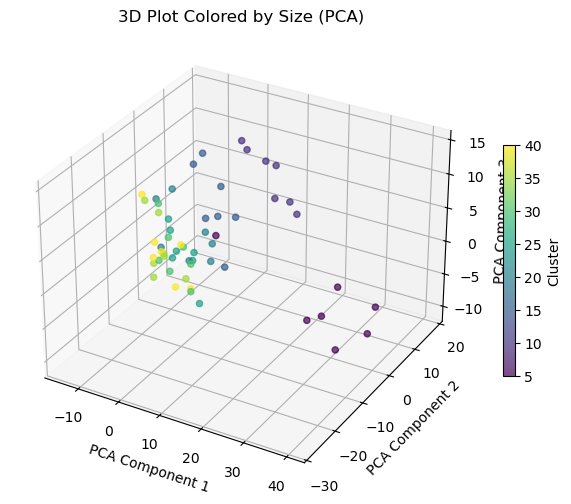

In [7]:
# 3D Plot of clusters colored by size
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

Sz = []
for i in range(56):
    Sz.append(((i%8)*5)+5)

df['Size'] = Sz

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1, depthshade=False)

# Labels and titled
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D Plot Colored by Size (PCA)")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()

### K means after PCA in 2D

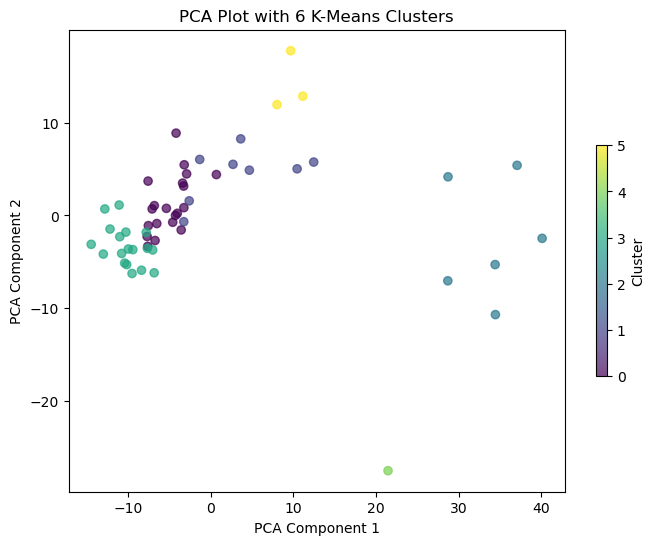

In [8]:
# Apply K-Means clustering on the PCA results
optimal_k = 6  # Choose the optimal number of clusters (could be determined using the elbow method)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Plot PCA results with clusters
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7)

# Add labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title(f"PCA Plot with {optimal_k} K-Means Clusters")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()


### PCA Component Reduction Labeled by Size in 2D

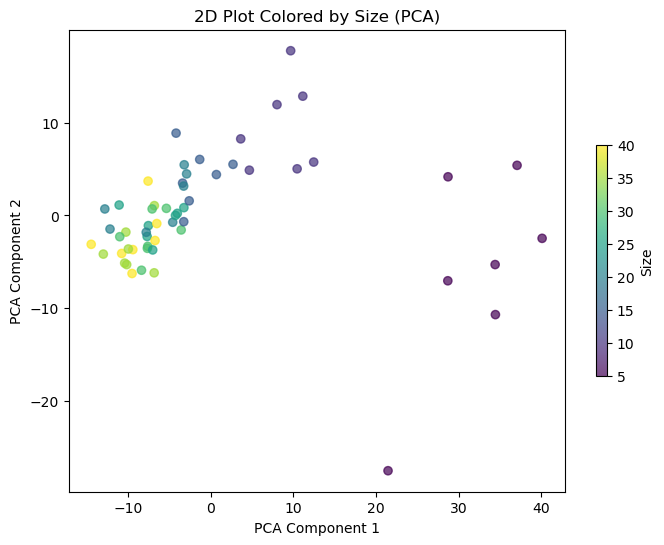

In [10]:
# 2D Plot of clusters colored by size
fig, ax = plt.subplots(figsize=(8, 6))

Sz = []
for i in range(56):
    Sz.append(((i % 8) * 5) + 5)

df['Size'] = Sz

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("2D Plot Colored by Size (PCA)")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Size")

plt.show()

### Attempting PCA for Extended Network

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("ExtNet_copy.csv", header=None)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Scaled data shape:", X_scaled.shape)

# Apply PCA (automatically uses max components = 8)
pca = PCA()
pca.fit(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Print contribution of each principal component
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f} ({ratio*100:.2f}% of total variance)")

# Optional: cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print("\nCumulative Variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")

Scaled data shape: (7560, 8)
Principal Component 1: 0.3094 (30.94% of total variance)
Principal Component 2: 0.1722 (17.22% of total variance)
Principal Component 3: 0.1290 (12.90% of total variance)
Principal Component 4: 0.0991 (9.91% of total variance)
Principal Component 5: 0.0839 (8.39% of total variance)
Principal Component 6: 0.0739 (7.39% of total variance)
Principal Component 7: 0.0674 (6.74% of total variance)
Principal Component 8: 0.0652 (6.52% of total variance)

Cumulative Variance:
PC1 to PC1: 0.3094 (30.94%)
PC1 to PC2: 0.4816 (48.16%)
PC1 to PC3: 0.6106 (61.06%)
PC1 to PC4: 0.7096 (70.96%)
PC1 to PC5: 0.7936 (79.36%)
PC1 to PC6: 0.8674 (86.74%)
PC1 to PC7: 0.9348 (93.48%)
PC1 to PC8: 1.0000 (100.00%)


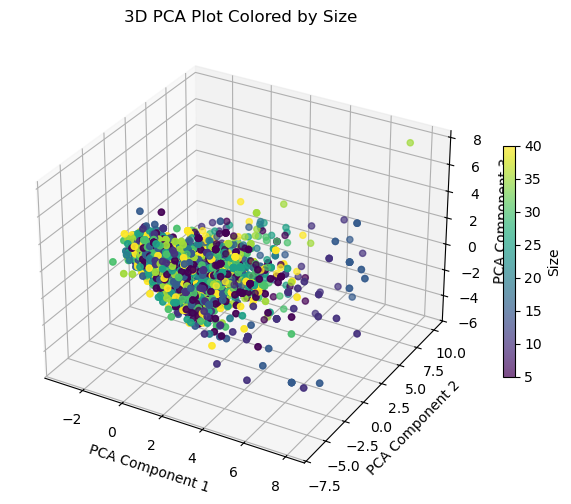

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure PCA has 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Generate Size labels (based on repeating pattern of 8)
Sz = [((i % 8) * 5) + 5 for i in range(len(df))]
df['Size'] = Sz

# Create 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=df['Size'],
    cmap='viridis',
    alpha=0.7,
    depthshade=False
)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D PCA Plot Colored by Size")

# Color bar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Size")

plt.show()

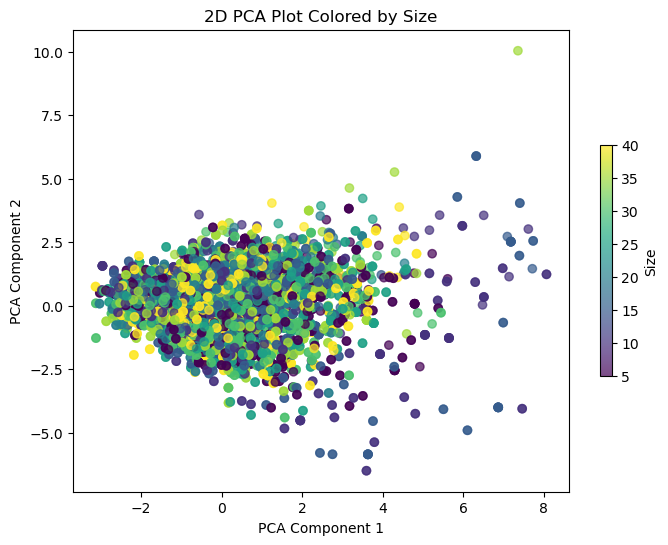

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure PCA has at least 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Generate Size labels dynamically
Sz = [((i % 8) * 5) + 5 for i in range(len(df))]
df['Size'] = Sz

# Create 2D plot
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Size'],
    cmap='viridis',
    alpha=0.7
)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("2D PCA Plot Colored by Size")

# Color bar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Size")

plt.show()